# Quick analysis: PEVmean-GA vs random

This notebook gives a short comparison of `pevmean_ga` against `random_individual` from the latest run.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('../outputs/pevmean_ga2/pevmean_ga_results.csv')
df = pd.read_csv(csv_path)
df.head()

,n_individuals,corr_eval,mse_adj,method,order_seed,pevmean_obj,target_island,target_island_name,repeat,repeat_seed,trait
0,4500,0.216164,0.902630,pevmean_ga,-1,16785.824998,3,Selvær,0,261820732,body_mass
1,4500,0.222029,0.893152,random_individual,0,NaN,3,Selvær,0,261820732,body_mass
2,4500,0.189334,0.906699,random_individual,1,NaN,3,Selvær,0,261820732,body_mass
3,4500,0.199134,0.901573,random_individual,2,NaN,3,Selvær,0,261820732,body_mass
4,4500,0.240552,0.893982,random_individual,3,NaN,3,Selvær,0,261820732,body_mass


In [22]:
summary = (
    df.groupby(['method', 'n_individuals'], as_index=False)
      .agg(
          corr_mean=('corr_eval', 'mean'),
          corr_std=('corr_eval', 'std'),
          mse_mean=('mse_adj', 'mean'),
          n_rows=('corr_eval', 'size')
      )
      .sort_values(['n_individuals', 'method'])
)
summary

,method,n_individuals,corr_mean,corr_std,mse_mean,n_rows
0,pevmean_ga,50,0.154682,0.023714,0.964057,5
13,random_individual,50,0.036397,0.066033,0.953399,25
1,pevmean_ga,100,0.186728,0.031853,0.932773,5
14,random_individual,100,0.018172,0.065299,0.931083,25
2,pevmean_ga,250,0.227594,0.029680,0.894278,5
15,random_individual,250,0.055812,0.074195,0.925251,25
3,pevmean_ga,500,0.183132,0.056669,0.908356,5
16,random_individual,500,0.077572,0.043423,0.923075,25
4,pevmean_ga,1000,0.194732,0.040968,0.905354,5
17,random_individual,1000,0.112076,0.061828,0.916169,25


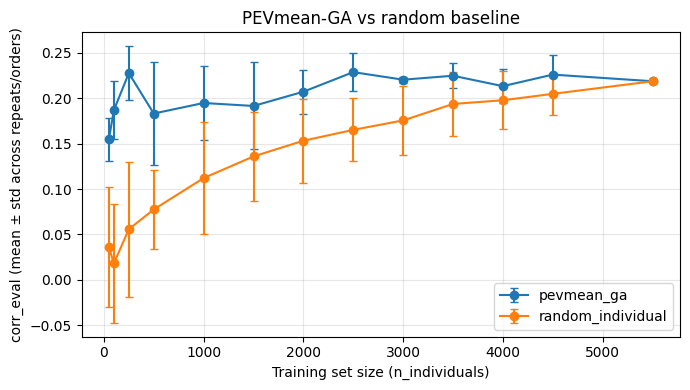

In [23]:
plot_df = summary.copy()
methods = plot_df['method'].unique().tolist()
x_vals = sorted(plot_df['n_individuals'].unique())

plt.figure(figsize=(7, 4))
for method in methods:
    sub = plot_df[plot_df['method'] == method].sort_values('n_individuals')
    plt.errorbar(
        sub['n_individuals'],
        sub['corr_mean'],
        yerr=sub['corr_std'].fillna(0.0),
        marker='o',
        capsize=3,
        label=method
    )

plt.xlabel('Training set size (n_individuals)')
plt.ylabel('corr_eval (mean ± std across repeats/orders)')
plt.title('PEVmean-GA vs random baseline')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Gain vs full-training baseline

This compares each subset result to training on the full available source set (same repeat seed). Positive values mean the subset outperforms the full-set model on `corr_eval`.

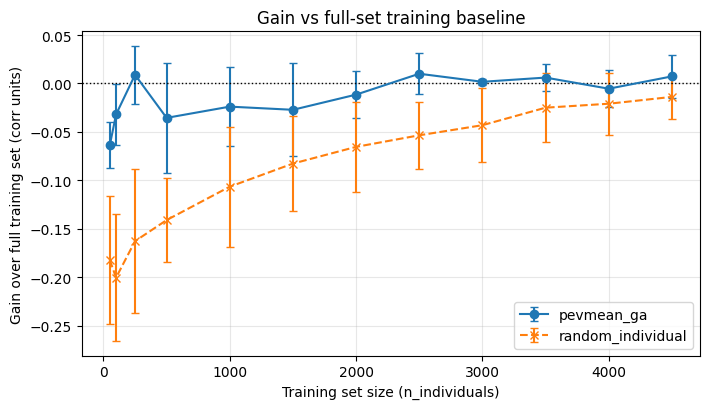

In [24]:
# Gain over training on full training set (per repeat)

full_n = int(df['n_individuals'].max())

# Use full-set PEVmean row as baseline per repeat (order_seed = -2 if present)
full_baseline = df[(df['n_individuals'] == full_n) & (df['method'] == 'pevmean_ga')].copy()
if full_baseline.empty:
    # fallback: use any method at full_n
    full_baseline = df[df['n_individuals'] == full_n].copy()

full_baseline = (
    full_baseline.groupby(['repeat', 'repeat_seed'], as_index=False)['corr_eval']
    .mean()
    .rename(columns={'corr_eval': 'corr_full'})
)

gain_df = df.merge(full_baseline, on=['repeat', 'repeat_seed'], how='inner')
gain_df['gain_over_full'] = gain_df['corr_eval'] - gain_df['corr_full']

# Focus on subset sizes for plotting
gain_plot = gain_df[gain_df['n_individuals'] < full_n].copy()

gain_summary = (
    gain_plot.groupby(['method', 'n_individuals'], as_index=False)
    .agg(
        gain_mean=('gain_over_full', 'mean'),
        gain_std=('gain_over_full', 'std'),
        frac_positive=('gain_over_full', lambda s: float(np.mean(s > 0))),
        n=('gain_over_full', 'size')
    )
    .sort_values(['n_individuals', 'method'])
)

plt.figure(figsize=(7.2, 4.2))
for method, sub in gain_summary.groupby('method'):
    sub = sub.sort_values('n_individuals')
    marker = 'x' if method == 'random_individual' else 'o'
    linestyle = '--' if method == 'random_individual' else '-'
    plt.errorbar(
        sub['n_individuals'],
        sub['gain_mean'],
        yerr=sub['gain_std'].fillna(0.0),
        marker=marker,
        linestyle=linestyle,
        capsize=3,
        label=method,
    )

plt.axhline(0.0, color='black', linewidth=1, linestyle=':')
plt.xlabel('Training set size (n_individuals)')
plt.ylabel('Gain over full training set (corr units)')
plt.title('Gain vs full-set training baseline')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Where selected birds come from (PEVmean-GA)

This section uses the stored `pevmean_ga_selected_individuals.csv` output directly (no GA rerun).

It aggregates selected individuals by source island, repeat, and training size to show composition.

In [25]:
# Build composition table directly from stored selected-individuals output (no GA rerun)
from pathlib import Path

candidate_paths = [
    Path('../outputs/pevmean_ga2/pevmean_ga_selected_individuals.csv'),
    Path('../outputs/pevmean_ga/pevmean_ga_selected_individuals.csv'),
]

selected_path = next((p for p in candidate_paths if p.exists()), None)
if selected_path is None:
    raise FileNotFoundError(
        'Could not find pevmean_ga_selected_individuals.csv in expected output folders.'
    )

selected_df = pd.read_csv(selected_path)
print(f'Loaded selected individuals: {selected_path} ({len(selected_df)} rows)')

# Keep only PEVmean rows matching the currently analyzed subset (trait/target/repeats/train sizes in `df`)
selected_df = selected_df[selected_df['method'] == 'pevmean_ga'].copy()

size_col_df = 'n_train_size' if 'n_train_size' in df.columns else 'n_individuals'
size_col_sel = 'n_train_size' if 'n_train_size' in selected_df.columns else 'n_individuals'

join_keys_df = ['trait', 'target_island', 'repeat', 'repeat_seed', size_col_df]
join_keys_sel = ['trait', 'target_island', 'repeat', 'repeat_seed', size_col_sel]

avail = df[df['method'] == 'pevmean_ga'][join_keys_df].drop_duplicates().copy()
if size_col_df != 'n_train_size':
    avail = avail.rename(columns={size_col_df: 'n_train_size'})

if size_col_sel != 'n_train_size':
    selected_df = selected_df.rename(columns={size_col_sel: 'n_train_size'})

selected_df = selected_df.merge(
    avail[['trait', 'target_island', 'repeat', 'repeat_seed', 'n_train_size']],
    on=['trait', 'target_island', 'repeat', 'repeat_seed', 'n_train_size'],
    how='inner',
)

# Aggregate to same schema expected by the next cell
counts = (
    selected_df.groupby(
        ['repeat', 'repeat_seed', 'n_train_size', 'source_island', 'source_island_name'],
        as_index=False,
    )
    .agg(n_selected=('ringnumber', 'size'))
)

counts['n_individuals'] = counts['n_train_size'].astype(int)
counts['frac_selected'] = counts['n_selected'] / counts['n_individuals']

comp_df = counts.rename(
    columns={
        'source_island': 'source_code',
        'source_island_name': 'source_name',
    }
)[['repeat', 'repeat_seed', 'n_individuals', 'source_code', 'source_name', 'n_selected', 'frac_selected']]

print(f'Composition rows: {len(comp_df)}')
comp_df.head(20)

Loaded selected individuals: ..\outputs\pevmean_ga2\pevmean_ga_selected_individuals.csv (114500 rows)
Composition rows: 856


,repeat,repeat_seed,n_individuals,source_code,source_name,n_selected,frac_selected
0,0,261820732,50,1,Myken,10,0.20
1,0,261820732,50,2,Træna,30,0.60
2,0,261820732,50,5,Hestmannøy,6,0.12
3,0,261820732,50,7,Onøy og Lurøy,1,0.02
4,0,261820732,50,8,Lovund,1,0.02
5,0,261820732,50,9,Sleneset,1,0.02
6,0,261820732,50,11,Southern 1,1,0.02
7,0,261820732,100,0,Nesøy,1,0.01
8,0,261820732,100,1,Myken,10,0.10
9,0,261820732,100,2,Træna,42,0.42


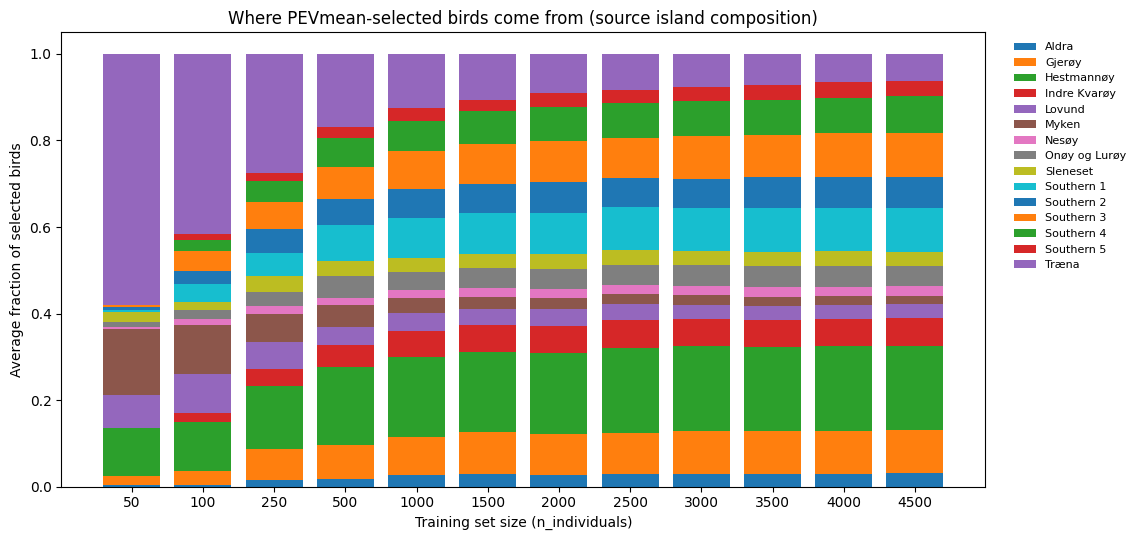

,n_individuals,source_name,mean_frac,mean_count,n_rows
0,50,Træna,0.580000,29.0,5
1,50,Myken,0.152000,7.6,5
2,50,Hestmannøy,0.112000,5.6,5
3,50,Lovund,0.076000,3.8,5
4,50,Sleneset,0.024000,1.2,5
5,100,Træna,0.416000,41.6,5
6,100,Myken,0.114000,11.4,5
7,100,Hestmannøy,0.114000,11.4,5
8,100,Lovund,0.090000,9.0,5
9,100,Southern 3,0.046000,4.6,5


In [26]:
# Composition overview figure

# Ensure missing (repeat, island) combinations are treated as zero before averaging.
all_repeats = sorted(comp_df['repeat'].unique().tolist())
all_sizes = sorted(comp_df['n_individuals'].unique().tolist())
all_islands = sorted(comp_df['source_name'].unique().tolist())

full_index = pd.MultiIndex.from_product(
    [all_repeats, all_sizes, all_islands],
    names=['repeat', 'n_individuals', 'source_name']
)

comp_repeat = (
    comp_df.groupby(['repeat', 'n_individuals', 'source_name'], as_index=False)
    .agg(
        frac_selected=('frac_selected', 'sum'),
        n_selected=('n_selected', 'sum')
    )
    .set_index(['repeat', 'n_individuals', 'source_name'])
    .reindex(full_index, fill_value=0.0)
    .reset_index()
)

comp_mean = (
    comp_repeat.groupby(['n_individuals', 'source_name'], as_index=False)
    .agg(
        mean_frac=('frac_selected', 'mean'),
        mean_count=('n_selected', 'mean'),
        n_rows=('repeat', 'size'),
    )
)

pivot_frac = comp_mean.pivot(index='n_individuals', columns='source_name', values='mean_frac').fillna(0.0)
pivot_frac = pivot_frac.sort_index()

plt.figure(figsize=(11.5, 5.5))
bottom = np.zeros(len(pivot_frac), dtype=float)
for col in pivot_frac.columns:
    vals = pivot_frac[col].to_numpy(dtype=float)
    if np.allclose(vals, 0.0):
        continue
    plt.bar(pivot_frac.index.astype(str), vals, bottom=bottom, label=col)
    bottom += vals

plt.ylabel('Average fraction of selected birds')
plt.xlabel('Training set size (n_individuals)')
plt.title('Where PEVmean-selected birds come from (source island composition)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Top contributors table
top_contrib = (
    comp_mean.sort_values(['n_individuals', 'mean_frac'], ascending=[True, False])
    .groupby('n_individuals', as_index=False)
    .head(5)
    .reset_index(drop=True)
)

top_contrib

## PEVmean objective and island contribution diagnostics

Additional diagnostics:
- Scatter of `PEVmean objective` vs `correlation score`.
- Expected vs actual island contribution counts.
- Fraction of available birds from each island that get selected.

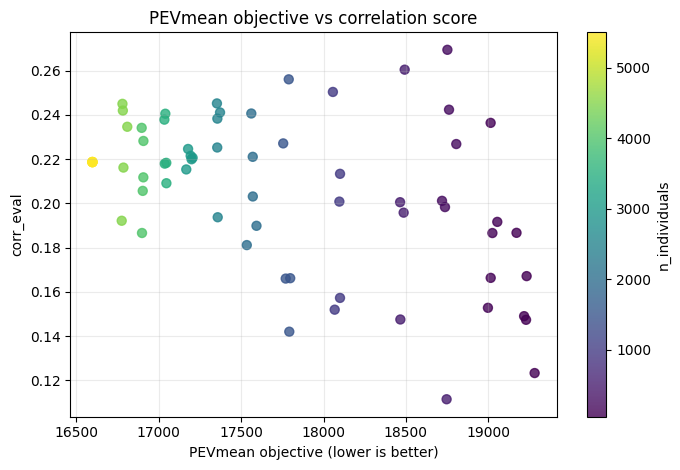

Pearson corr(PEV objective, corr_eval) = -0.4578


In [27]:
# Scatter: PEVmean objective vs correlation score

pev_scatter = df[df['method'] == 'pevmean_ga'].copy()
pev_scatter = pev_scatter[np.isfinite(pev_scatter['pevmean_obj'])].copy()

plt.figure(figsize=(7.0, 4.8))
sc = plt.scatter(
    pev_scatter['pevmean_obj'],
    pev_scatter['corr_eval'],
    c=pev_scatter['n_individuals'],
    cmap='viridis',
    alpha=0.8,
    s=42,
)

cbar = plt.colorbar(sc)
cbar.set_label('n_individuals')

plt.xlabel('PEVmean objective (lower is better)')
plt.ylabel('corr_eval')
plt.title('PEVmean objective vs correlation score')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

corr_obj = pev_scatter[['pevmean_obj', 'corr_eval']].corr().iloc[0, 1]
print(f'Pearson corr(PEV objective, corr_eval) = {corr_obj:.4f}')

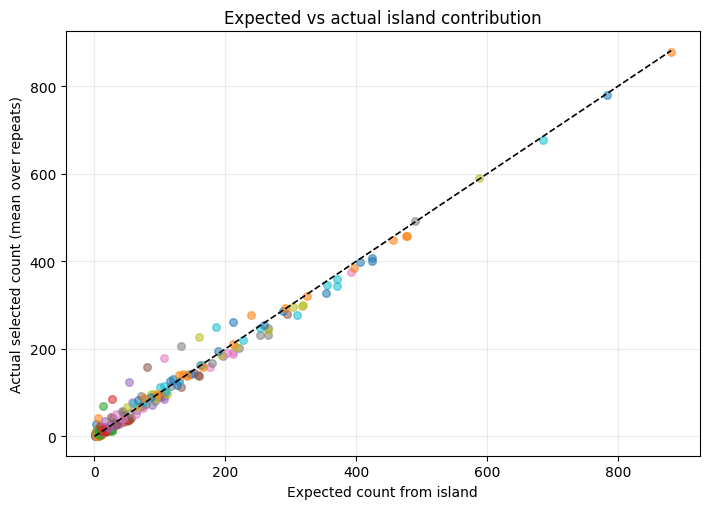

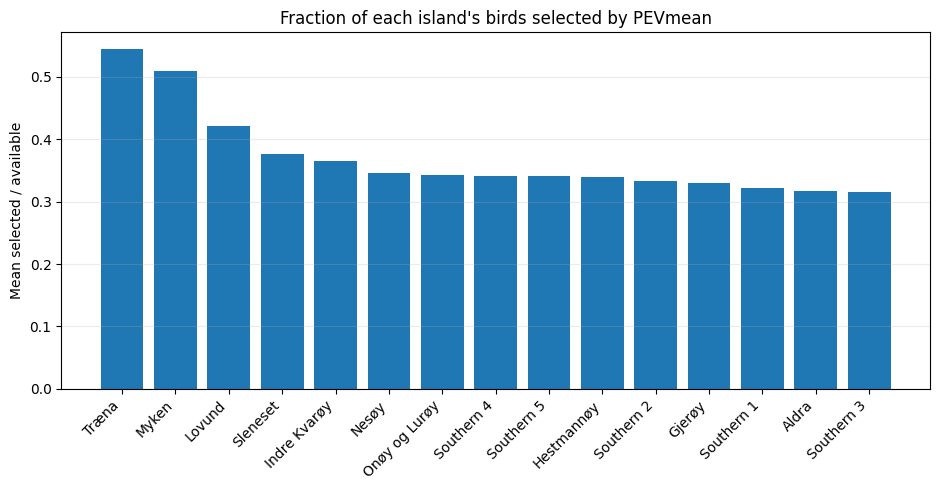

,n_individuals,source_name,expected_count,actual_count,contribution_lift,selection_fraction_of_available
2,50,Træna,2.653098,29.00,26.346902,0.099315
1,50,Myken,0.835908,7.60,6.764092,0.082609
6,50,Lovund,1.435581,3.80,2.364419,0.024051
0,50,Nesøy,1.081228,1.00,-0.081228,0.008403
7,50,Sleneset,1.508268,1.20,-0.308268,0.007229
14,100,Træna,5.306197,41.60,36.293803,0.142466
13,100,Myken,1.671815,11.40,9.728185,0.123913
19,100,Lovund,2.871161,9.00,6.128839,0.056962
12,100,Nesøy,2.162457,1.75,-0.412457,0.014706
21,100,Aldra,3.143740,2.00,-1.143740,0.011561


In [28]:
# Expected vs actual island contribution, and selection fraction of available birds
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_data

# Load source island pool counts (potential contribution)
config_path = Path('../config/pevmean_ga_config.json')
with open(config_path, 'r') as f:
    cfg = json.load(f)

trait_cfg = None
for t in cfg.get('traits', []):
    if str(t.get('name')) == 'body_mass':
        trait_cfg = t
        break
if trait_cfg is None:
    raise ValueError('Could not find trait=body_mass in config')

paths = dict(cfg['paths'])
paths['npz'] = trait_cfg['npz']
for k, v in list(paths.items()):
    if isinstance(v, str):
        p = Path(v)
        if not p.is_absolute():
            p = (ROOT / p).resolve()
        paths[k] = str(p)

X, y, ids, GRM_df, locality, code_to_label, y_eval = load_data(
    paths=paths,
    target_column=trait_cfg.get('target_column', cfg.get('target_column', 'y_adjusted')),
    standardize_features=trait_cfg.get('standardize_features', cfg.get('standardize_features', True)),
    return_locality=True,
    min_count=int(trait_cfg.get('min_count', cfg.get('min_count', 20))),
    return_eval=True,
    eval_target_column=trait_cfg.get('eval_target_column', cfg.get('eval_target_column', 'y_mean')),
)

target_code = int(df['target_island'].iloc[0])
source_locality = locality[locality != target_code]

pool_df = (
    pd.Series(source_locality)
    .value_counts()
    .sort_index()
    .rename_axis('source_code')
    .reset_index(name='pool_count')
)

# Use names from comp_df (already mapped from selected-individuals file)
name_map = comp_df[['source_code', 'source_name']].drop_duplicates()
pool_df = pool_df.merge(name_map, on='source_code', how='left')

N_source = int(pool_df['pool_count'].sum())
pool_df['pool_frac'] = pool_df['pool_count'] / N_source

# Actual selected counts/fractions from PEVmean selections
actual_df = (
    comp_df.groupby(['n_individuals', 'source_code', 'source_name'], as_index=False)
    .agg(
        actual_count=('n_selected', 'mean'),
        actual_frac_in_train=('frac_selected', 'mean'),
    )
)

exp_act = actual_df.merge(pool_df[['source_code', 'pool_count', 'pool_frac']], on='source_code', how='left')
exp_act['expected_count'] = exp_act['n_individuals'] * exp_act['pool_frac']
exp_act['selection_fraction_of_available'] = exp_act['actual_count'] / exp_act['pool_count']
exp_act['contribution_lift'] = exp_act['actual_count'] - exp_act['expected_count']

# ---- Figure A: expected vs actual counts (across all train sizes) ----
plt.figure(figsize=(7.2, 5.2))
for size, sub in exp_act.groupby('n_individuals'):
    plt.scatter(sub['expected_count'], sub['actual_count'], s=30, alpha=0.55, label=f'n={size}')

xy_max = max(float(exp_act['expected_count'].max()), float(exp_act['actual_count'].max()))
plt.plot([0, xy_max], [0, xy_max], linestyle='--', linewidth=1.2, color='black')

plt.xlabel('Expected count from island')
plt.ylabel('Actual selected count (mean over repeats)')
plt.title('Expected vs actual island contribution')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---- Figure B: fraction of available birds selected ----
coverage = (
    exp_act.groupby(['source_name'], as_index=False)
    .agg(
        mean_fraction_selected=('selection_fraction_of_available', 'mean'),
        mean_lift=('contribution_lift', 'mean'),
    )
    .sort_values('mean_fraction_selected', ascending=False)
)

plt.figure(figsize=(9.5, 5.0))
plt.bar(coverage['source_name'], coverage['mean_fraction_selected'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean selected / available')
plt.title('Fraction of each island\'s birds selected by PEVmean')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Show most over/under-contributing islands per train size
lift_table = exp_act[['n_individuals', 'source_name', 'expected_count', 'actual_count', 'contribution_lift', 'selection_fraction_of_available']].copy()

top_lift = (
    lift_table.sort_values(['n_individuals', 'contribution_lift'], ascending=[True, False])
    .groupby('n_individuals', as_index=False)
    .head(5)
)

top_lift